In [1]:
import sys
sys.path.append('..')

import pandas as pd
from src.visualize import plot_diabetes_trend, NORDIC_COLORS

df = pd.read_csv('../data/nordic_cleaned.csv')
print(df.shape)
df.head()

(198, 6)


,country,iso,year,diabetes_prevalence,treatment_rate,obesity_prevalence
0,Denmark,DNK,1990,0.026467,0.318880,8.57632
1,Denmark,DNK,1991,0.027161,0.323102,8.82850
2,Denmark,DNK,1992,0.027819,0.327693,9.09095
3,Denmark,DNK,1993,0.028435,0.332619,9.36231
4,Denmark,DNK,1994,0.028977,0.337866,9.64552


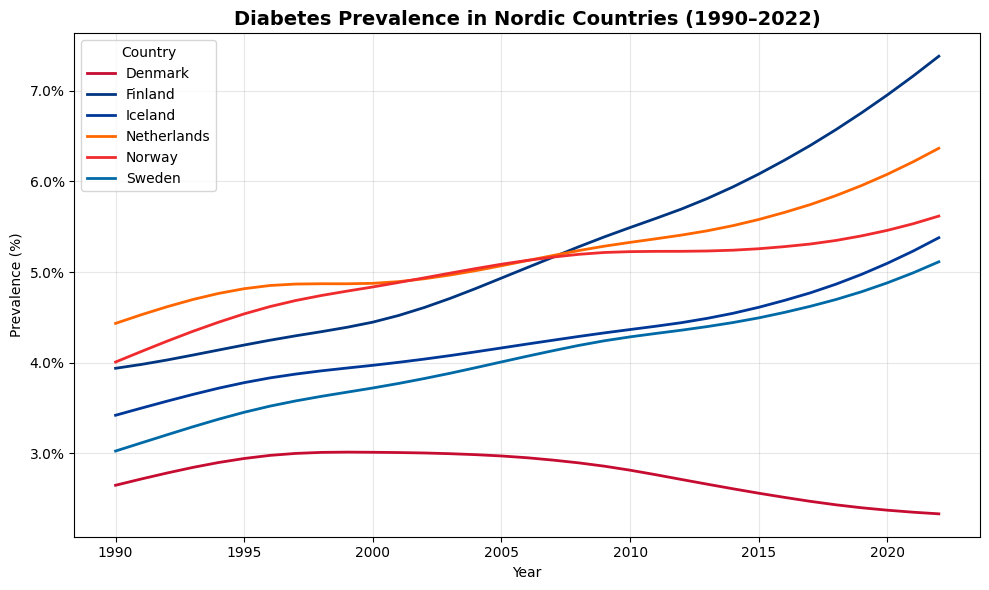

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

nordic_colors = {
    'Sweden': '#006AA7',
    'Norway': '#EF2B2D',
    'Denmark': '#C60C30',
    'Finland': '#003580',
    'Iceland': '#003897',
    'Netherlands': '#FF6600'
}

fig, ax = plt.subplots(figsize=(10, 6))

for country, group in df.groupby('country'):
    ax.plot(group['year'], group['diabetes_prevalence'] * 100,
            label=country,
            color=nordic_colors[country],
            linewidth=2)

ax.set_title('Diabetes Prevalence in Nordic Countries (1990–2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Prevalence (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.legend(title='Country')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/diabetes_trend.png', dpi=150)
plt.show()

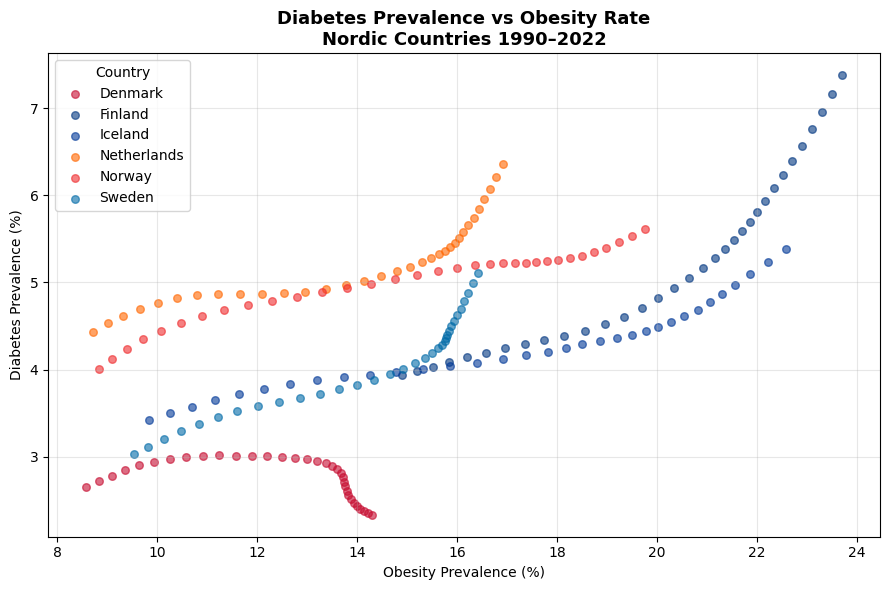

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))

for country, group in df.groupby('country'):
    ax.scatter(group['obesity_prevalence'],
               group['diabetes_prevalence'] * 100,
               label=country,
               color=nordic_colors[country],
               alpha=0.6,
               s=30)

ax.set_title('Diabetes Prevalence vs Obesity Rate\nNordic Countries 1990–2022', fontsize=13, fontweight='bold')
ax.set_xlabel('Obesity Prevalence (%)')
ax.set_ylabel('Diabetes Prevalence (%)')
ax.legend(title='Country')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/diabetes_vs_obesity.png', dpi=150)
plt.show()

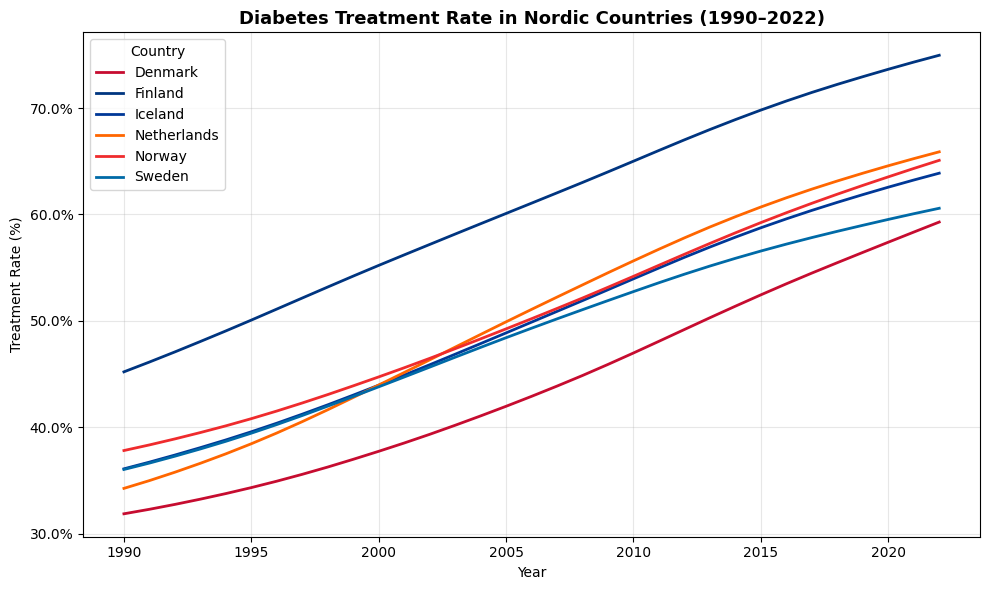

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for country, group in df.groupby('country'):
    ax.plot(group['year'], group['treatment_rate'] * 100,
            label=country,
            color=nordic_colors[country],
            linewidth=2)

ax.set_title('Diabetes Treatment Rate in Nordic Countries (1990–2022)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Treatment Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.legend(title='Country')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/treatment_trend.png', dpi=150)
plt.show()

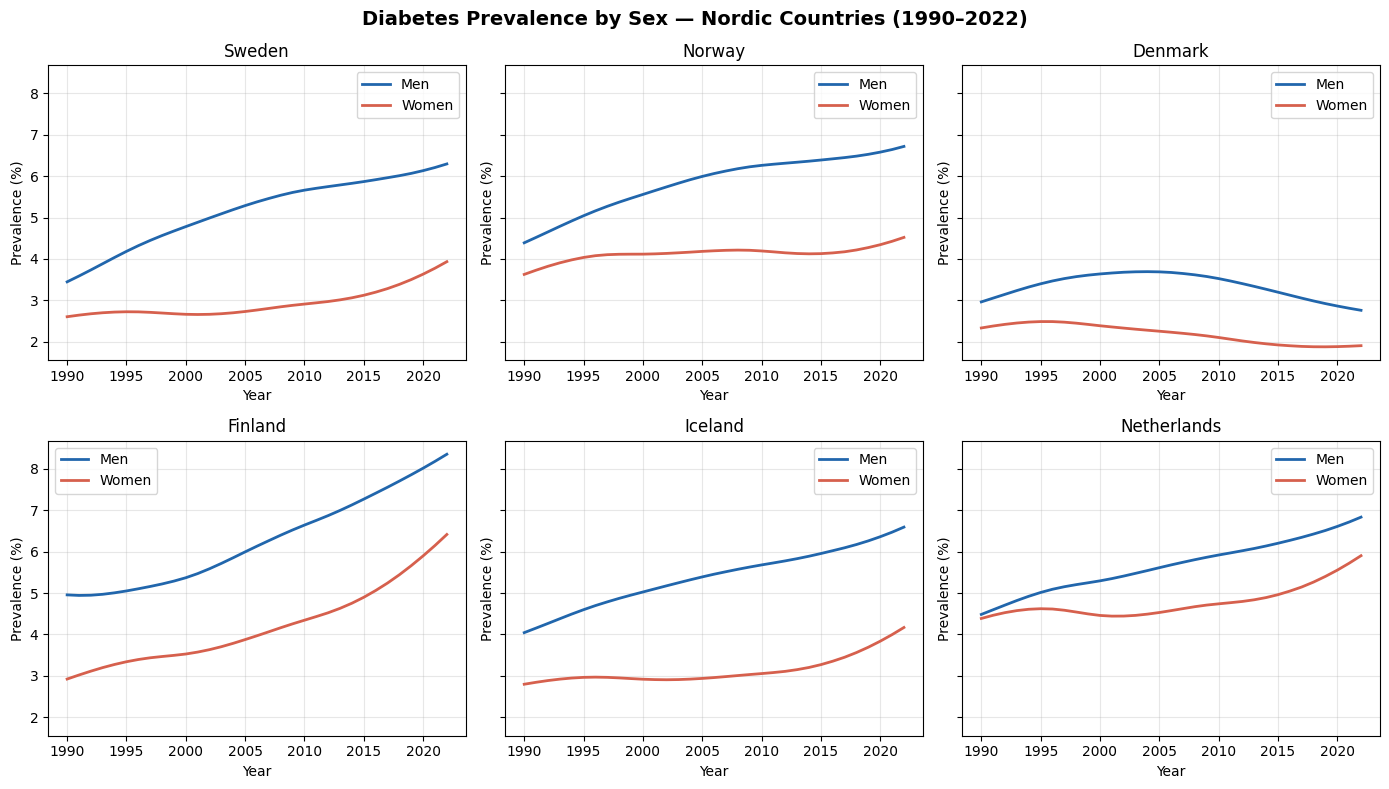

In [5]:
nordic = ['Sweden', 'Norway', 'Denmark', 'Finland', 'Iceland', 'Netherlands']

df_sex = pd.read_csv('../data/diabetes.csv')
df_sex = df_sex.rename(columns={
    'Country/Region/World': 'country',
    'Sex': 'sex',
    'Year': 'year',
    'Prevalence of diabetes (18+ years)': 'diabetes_prevalence'
})

df_sex_nordic = df_sex[df_sex['country'].isin(nordic)]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for i, country in enumerate(nordic):
    df_c = df_sex_nordic[df_sex_nordic['country'] == country]
    for sex, color in [('Men', '#2166ac'), ('Women', '#d6604d')]:
        d = df_c[df_c['sex'] == sex]
        axes[i].plot(d['year'], d['diabetes_prevalence'] * 100,
                     label=sex, color=color, linewidth=2)
    axes[i].set_title(country)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Prevalence (%)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

fig.suptitle('Diabetes Prevalence by Sex — Nordic Countries (1990–2022)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/diabetes_by_sex.png', dpi=150)
plt.show()